# Diamond Price — Data Cleaning & Feature Engineering

Pipeline:
1. Drop ~20 rows with `x`, `y`, or `z` == 0 (physically impossible)
2. Ordinal-encode `cut`, `color`, `clarity` (worst → best, integer)
3. Engineer `volume = x*y*z`, `density = carat/volume`, `log_carat`
4. Save to `data/diamonds_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_zero_dimensions, encode_ordinals,
                   create_features, preprocess_data,
                   CUT_ORDER, COLOR_ORDER, CLARITY_ORDER)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/diamonds.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Missing / Invalid Values

In [3]:
print(f"NaN count: {df.isnull().sum().sum()}")
zero_dim = ((df["x"]==0) | (df["y"]==0) | (df["z"]==0)).sum()
print(f"Zero-dimension rows: {zero_dim}")

NaN count: 0
Zero-dimension rows: 20


## 3. Drop Zero-Dimension Rows

In [4]:
df_no_zero = drop_zero_dimensions(df)
print(f"After dropping zero-dim rows: {df_no_zero.shape}")

After dropping zero-dim rows: (53920, 10)


## 4. Ordinal Encoding

We encode cut/color/clarity as worst→best integers (0..N-1) so they preserve their natural order.

In [5]:
df_ord = encode_ordinals(df_no_zero)
print("Encoding maps:")
print(f"  cut    : {dict(enumerate(CUT_ORDER))}")
print(f"  color  : {dict(enumerate(COLOR_ORDER))}  # J=worst, D=best")
print(f"  clarity: {dict(enumerate(CLARITY_ORDER))}")
df_ord.head()

Encoding maps:
  cut    : {0: 'Fair', 1: 'Good', 2: 'Very Good', 3: 'Premium', 4: 'Ideal'}
  color  : {0: 'J', 1: 'I', 2: 'H', 3: 'G', 4: 'F', 5: 'E', 6: 'D'}  # J=worst, D=best
  clarity: {0: 'I1', 1: 'SI2', 2: 'SI1', 3: 'VS2', 4: 'VS1', 5: 'VVS2', 6: 'VVS1', 7: 'IF'}


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


## 5. Distribution Comparison Before/After Encoding

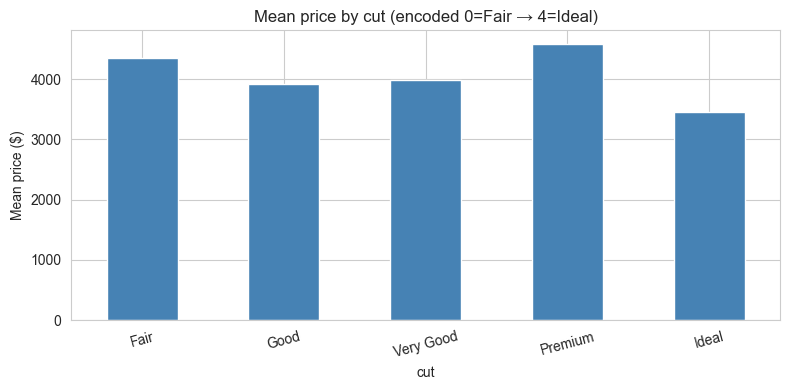

In [6]:
# Cut levels and corresponding integer codes
fig, ax = plt.subplots(figsize=(8, 4))
df_ord.groupby("cut")["price"].mean().plot(kind="bar", color="steelblue", ax=ax)
ax.set_xticklabels(CUT_ORDER, rotation=15)
ax.set_title("Mean price by cut (encoded 0=Fair → 4=Ideal)")
ax.set_ylabel("Mean price ($)")
plt.tight_layout(); plt.show()

## 6. Feature Engineering

In [7]:
df_feat = create_features(df_ord)
new_cols = [c for c in df_feat.columns if c not in df_ord.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["price"]].head()

New features: ['volume', 'density', 'log_carat']


,volume,density,log_carat,price
0,38.202030,0.006021,0.207014,326
1,34.505856,0.006086,0.190620,326
2,38.076885,0.006040,0.207014,327
3,46.724580,0.006207,0.254642,334
4,51.917250,0.005971,0.270027,335


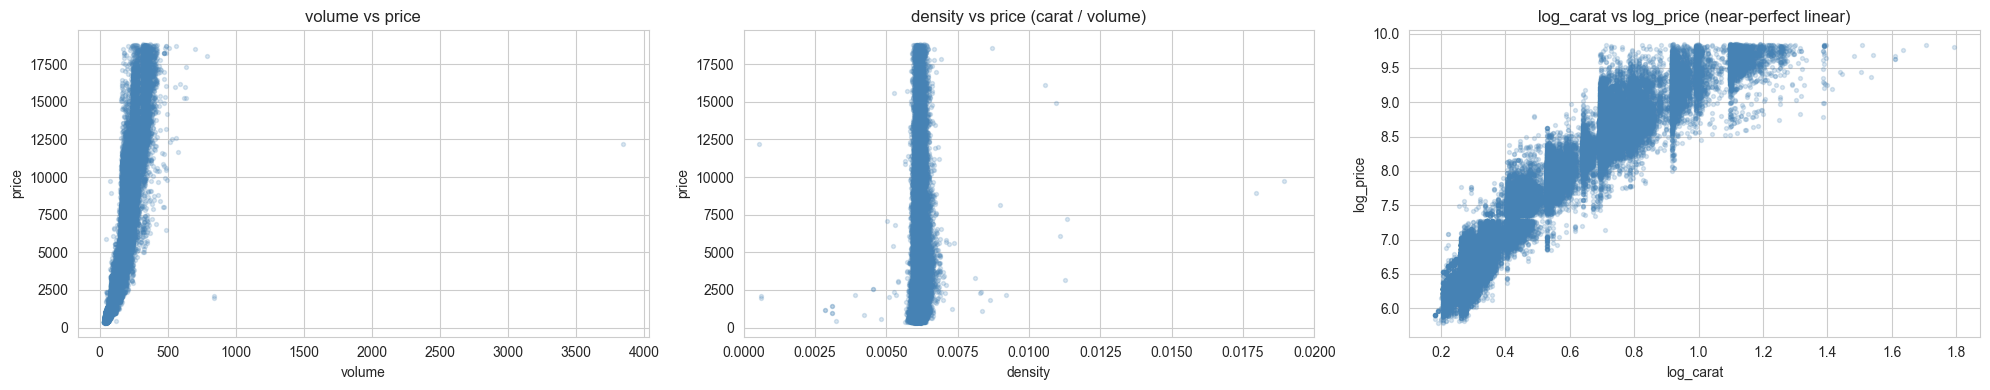

In [8]:
# Visualize new features
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
axes[0].scatter(df_feat["volume"], df_feat["price"], alpha=0.2, color="steelblue", s=8)
axes[0].set_xlabel("volume"); axes[0].set_ylabel("price")
axes[0].set_title("volume vs price")

axes[1].scatter(df_feat["density"], df_feat["price"], alpha=0.2, color="steelblue", s=8)
axes[1].set_xlabel("density"); axes[1].set_ylabel("price")
axes[1].set_title("density vs price (carat / volume)")
axes[1].set_xlim(0, 0.02)

axes[2].scatter(df_feat["log_carat"], np.log1p(df_feat["price"]),
                alpha=0.2, color="steelblue", s=8)
axes[2].set_xlabel("log_carat"); axes[2].set_ylabel("log_price")
axes[2].set_title("log_carat vs log_price (near-perfect linear)")
plt.tight_layout(); plt.show()

## 7. Run the Full Pipeline

In [9]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (53920, 13)
Missing values : 0


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density,log_carat
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,0.207014
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,0.190620
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,0.207014
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207,0.254642
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971,0.270027


## 8. Sanity Checks & Save

In [10]:
assert df_processed.isnull().sum().sum() == 0
assert "price" in df_processed.columns
assert (df_processed["x"] > 0).all() and (df_processed["y"] > 0).all() and (df_processed["z"] > 0).all()
print("All checks passed.")

All checks passed.


In [11]:
df_processed.to_csv("data/diamonds_cleaned.csv", index=False)
print(f"Saved data/diamonds_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/diamonds_cleaned.csv (53920 rows, 13 cols)
